In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from sqlalchemy import create_engine

In [2]:
engine = create_engine(r"sqlite:///C:\Users\ASUS\Desktop\Bluestock_MF_Capstone_Project\data\db\bluestock_mf.db")

In [3]:
nav = pd.read_sql("SELECT * FROM fact_nav", engine)
fund = pd.read_sql("SELECT * FROM dim_fund", engine)
aum = pd.read_sql("SELECT * FROM fact_aum", engine)
sip = pd.read_sql("SELECT * FROM fact_sip_industry", engine)
transactions = pd.read_sql("SELECT * FROM fact_transactions", engine)
performance = pd.read_sql("SELECT * FROM fact_performance", engine)
portfolio = pd.read_sql("SELECT * FROM fact_portfolio", engine)

print("All tables loaded")
print(f"NAV: {nav.shape}")
print(f"Fund: {fund.shape}")
print(f"AUM: {aum.shape}")
print(f"SIP: {sip.shape}")
print(f"Transactions: {transactions.shape}")
print(f"Performance: {performance.shape}")
print(f"Portfolio: {portfolio.shape}")

All tables loaded
NAV: (46000, 3)
Fund: (40, 15)
AUM: (90, 5)
SIP: (36, 6)
Transactions: (32778, 13)
Performance: (40, 19)
Portfolio: (322, 8)


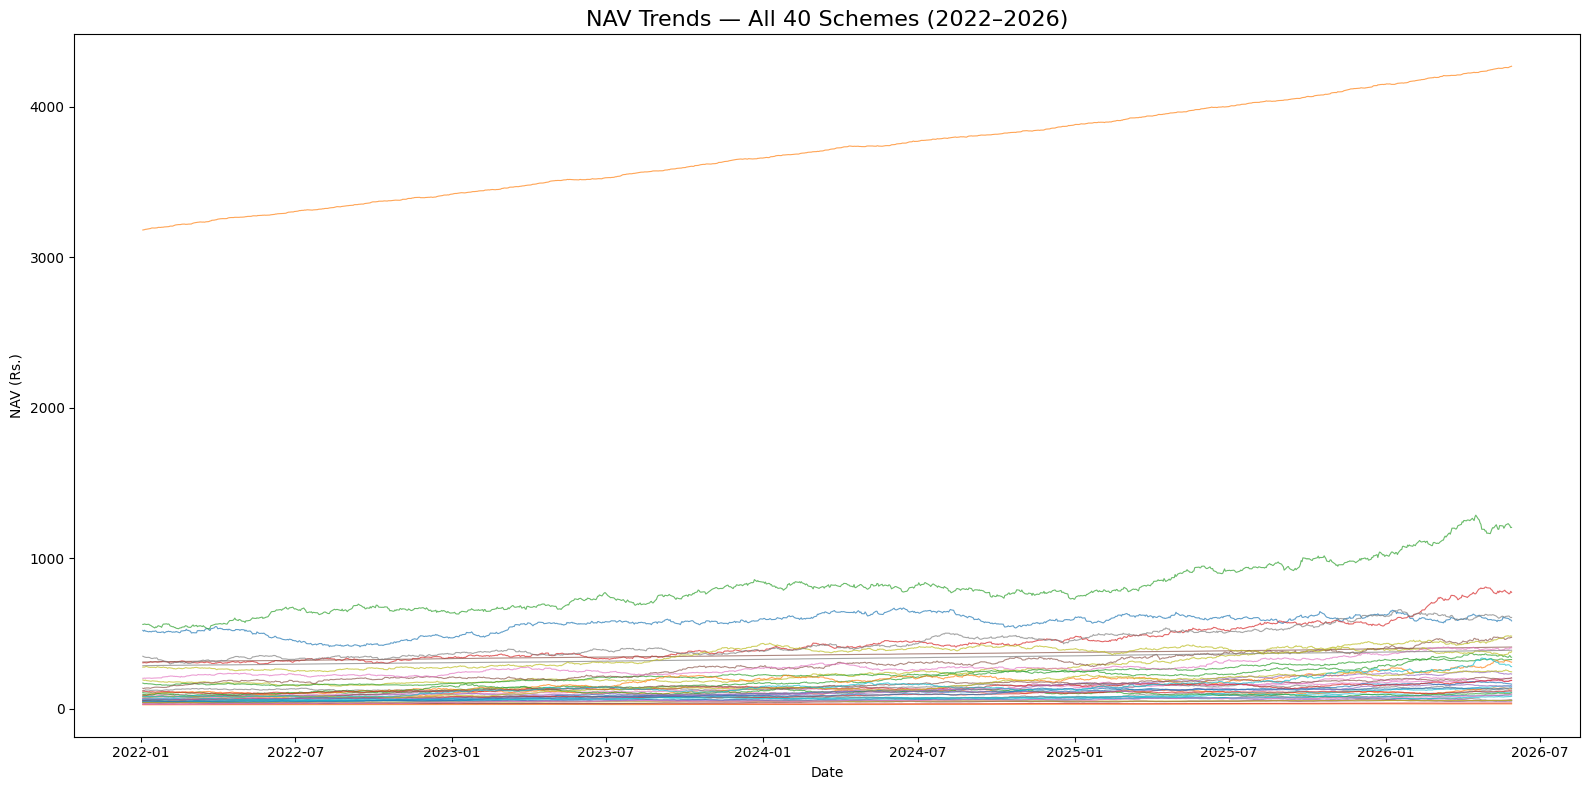

Chart 1 saved


In [4]:
nav['date'] = pd.to_datetime(nav['date'])
nav_merged = nav.merge(fund[['amfi_code', 'scheme_name']], on='amfi_code')

plt.figure(figsize=(16, 8))

for code in nav_merged['amfi_code'].unique():
    subset = nav_merged[nav_merged['amfi_code'] == code]
    plt.plot(subset['date'], subset['nav'], linewidth=0.8, alpha=0.7)

plt.title('NAV Trends — All 40 Schemes (2022–2026)', fontsize=16)
plt.xlabel('Date')
plt.ylabel('NAV (Rs.)')
plt.tight_layout()
plt.savefig(r"C:\Users\ASUS\Desktop\Bluestock_MF_Capstone_Project\reports\nav_trend.png", dpi=150)
plt.show()
print("Chart 1 saved")

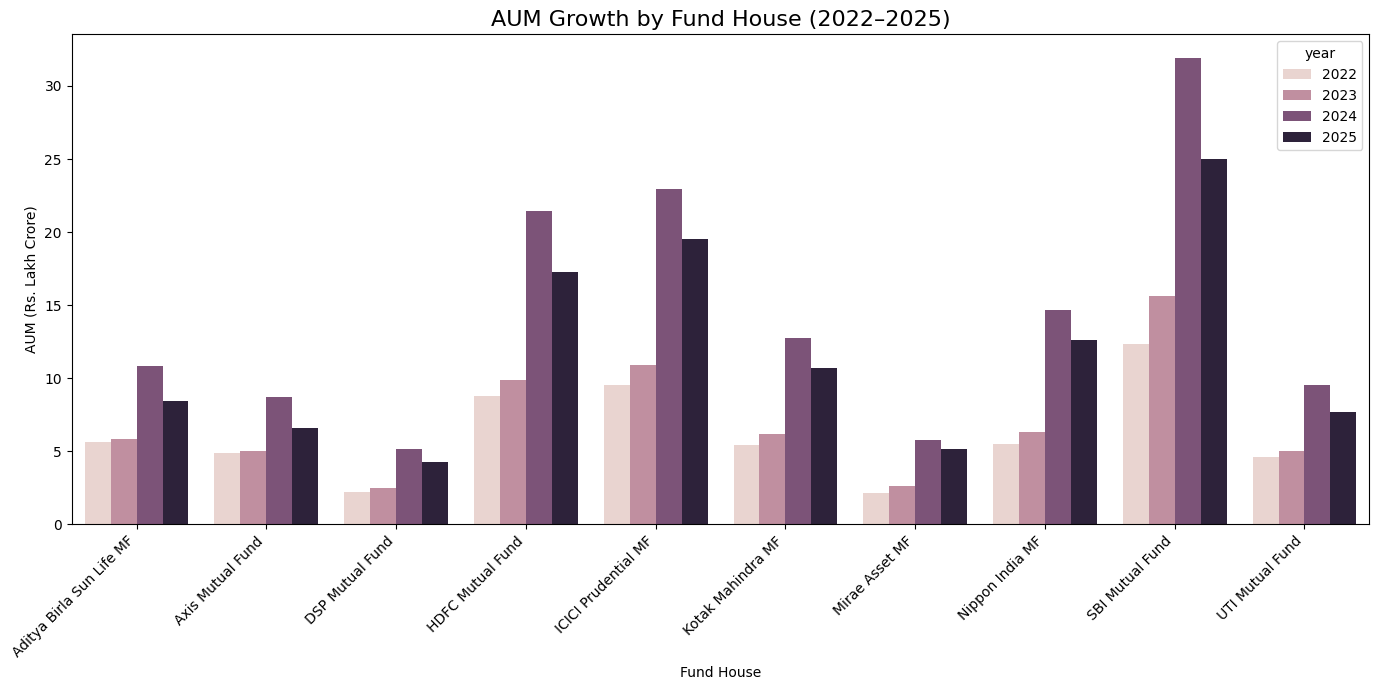

Chart 2 saved


In [5]:
aum['date'] = pd.to_datetime(aum['date'])
aum['year'] = aum['date'].dt.year
aum_grouped = aum.groupby(['fund_house', 'year'])['aum_lakh_crore'].sum().reset_index()

plt.figure(figsize=(14, 7))
sns.barplot(data=aum_grouped, x='fund_house', y='aum_lakh_crore', hue='year')
plt.title('AUM Growth by Fund House (2022–2025)', fontsize=16)
plt.xlabel('Fund House')
plt.ylabel('AUM (Rs. Lakh Crore)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(r"C:\Users\ASUS\Desktop\Bluestock_MF_Capstone_Project\reports\aum_growth.png", dpi=150)
plt.show()
print("Chart 2 saved")

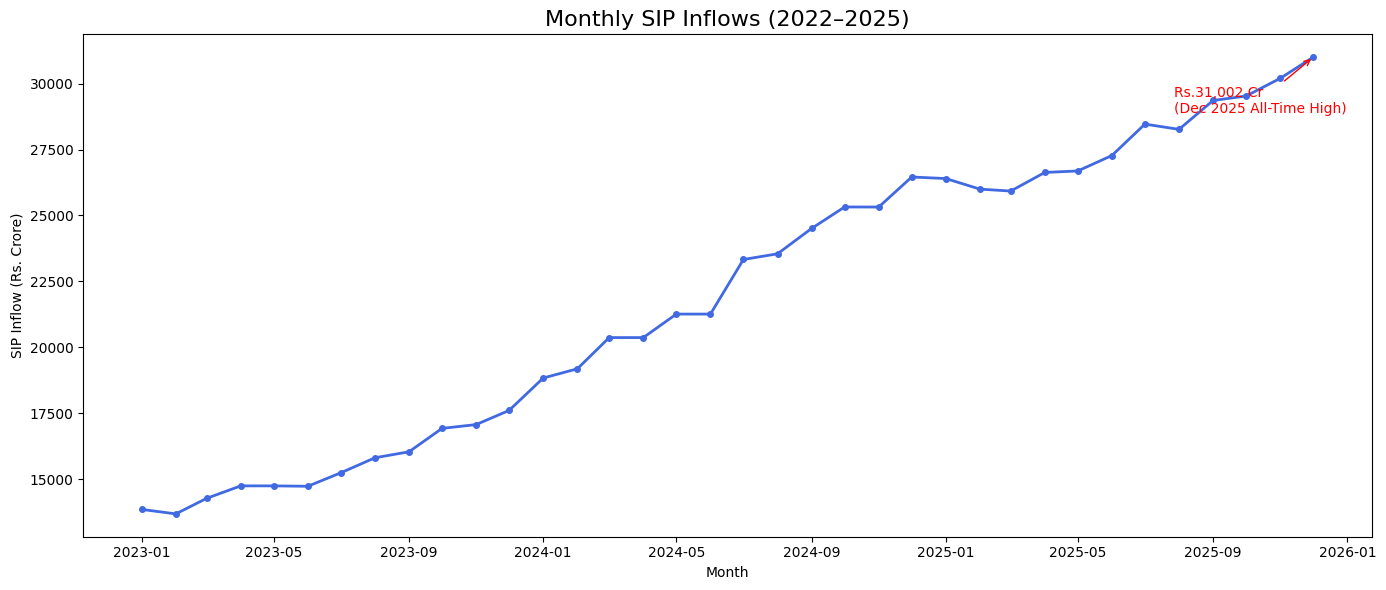

Chart 3 saved


In [6]:
sip['month'] = pd.to_datetime(sip['month'])

plt.figure(figsize=(14, 6))
plt.plot(sip['month'], sip['sip_inflow_crore'], 
         color='royalblue', linewidth=2, marker='o', markersize=4)

max_idx = sip['sip_inflow_crore'].idxmax()
plt.annotate(f"Rs.{sip['sip_inflow_crore'].max():,} Cr\n(Dec 2025 All-Time High)",
             xy=(sip['month'][max_idx], sip['sip_inflow_crore'][max_idx]),
             xytext=(-100, -40), textcoords='offset points',
             arrowprops=dict(arrowstyle='->', color='red'),
             fontsize=10, color='red')

plt.title('Monthly SIP Inflows (2022–2025)', fontsize=16)
plt.xlabel('Month')
plt.ylabel('SIP Inflow (Rs. Crore)')
plt.tight_layout()
plt.savefig(r"C:\Users\ASUS\Desktop\Bluestock_MF_Capstone_Project\reports\sip_inflow_trend.png", dpi=150)
plt.show()
print("Chart 3 saved")

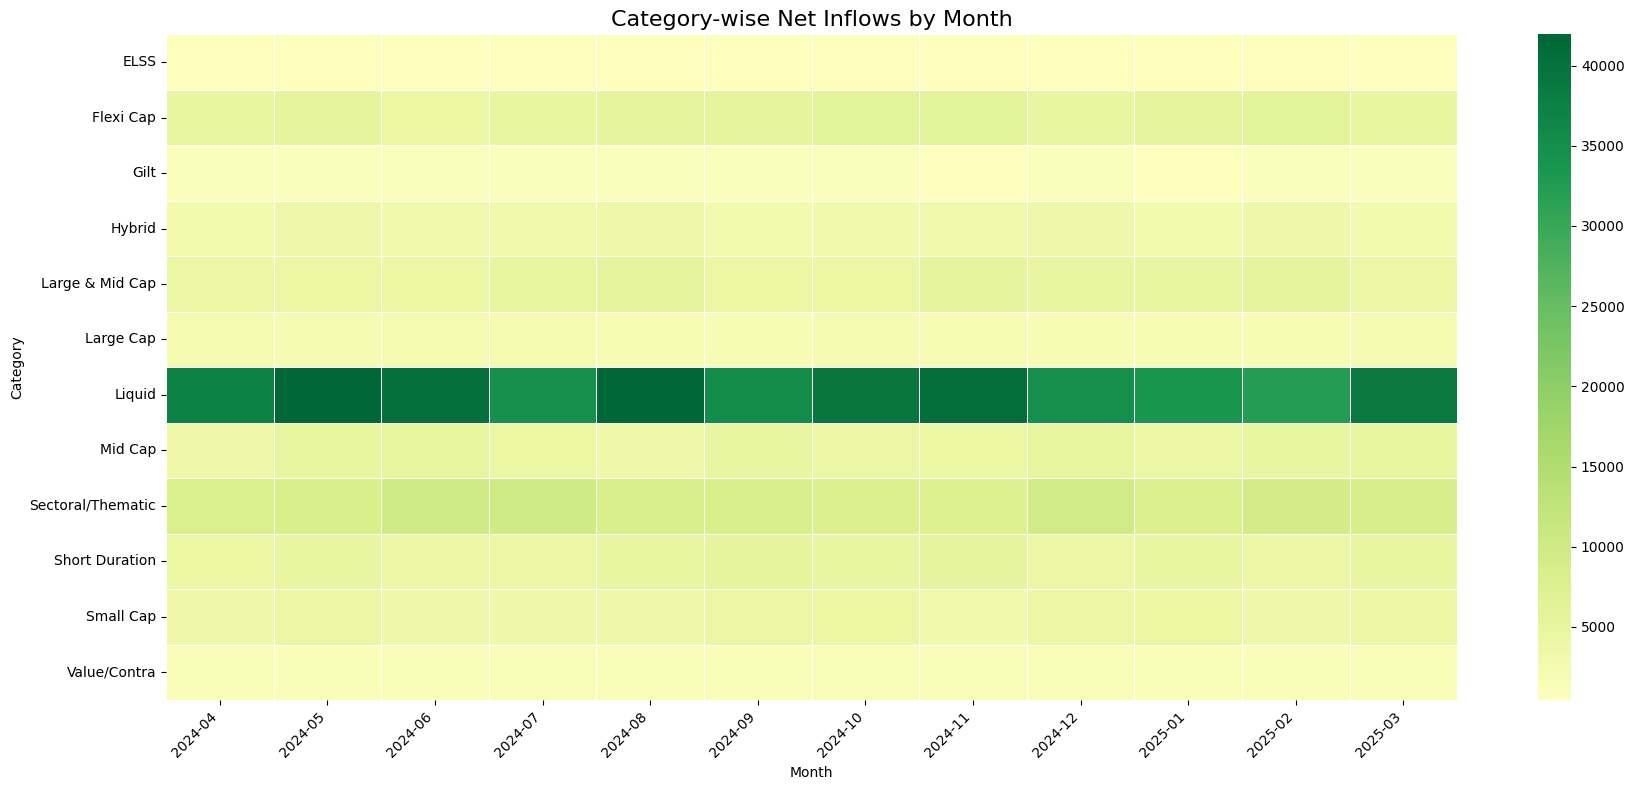

Chart 4 saved


In [8]:
cat_inflows['month'] = pd.to_datetime(cat_inflows['month'])
cat_inflows['month_str'] = cat_inflows['month'].dt.strftime('%Y-%m')

pivot = cat_inflows.pivot(index='category', columns='month_str', values='net_inflow_crore')

plt.figure(figsize=(18, 8))
sns.heatmap(pivot, cmap='RdYlGn', center=0, 
            linewidths=0.5, annot=False)
plt.title('Category-wise Net Inflows by Month', fontsize=16)
plt.xlabel('Month')
plt.ylabel('Category')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(r"C:\Users\ASUS\Desktop\Bluestock_MF_Capstone_Project\reports\category_heatmap.png", dpi=150)
plt.show()
print("Chart 4 saved")

In [16]:
folio = pd.read_csv(r"C:\Users\ASUS\Desktop\Bluestock_MF_Capstone_Project\data\processed\06_industry_folio_count.csv")
print(folio.columns.tolist())
print(folio.head())

['month', 'total_folios_crore', 'equity_folios_crore', 'debt_folios_crore', 'hybrid_folios_crore', 'others_folios_crore']
        month  total_folios_crore  equity_folios_crore  debt_folios_crore  \
0  2022-01-01               13.26                 9.28               1.86   
1  2022-04-01               13.91                 9.74               1.95   
2  2022-07-01               13.85                 9.69               1.94   
3  2022-10-01               14.12                 9.88               1.98   
4  2023-01-01               14.81                10.37               2.07   

   hybrid_folios_crore  others_folios_crore  
0                 0.80                 1.33  
1                 0.83                 1.39  
2                 0.83                 1.38  
3                 0.85                 1.41  
4                 0.89                 1.48  


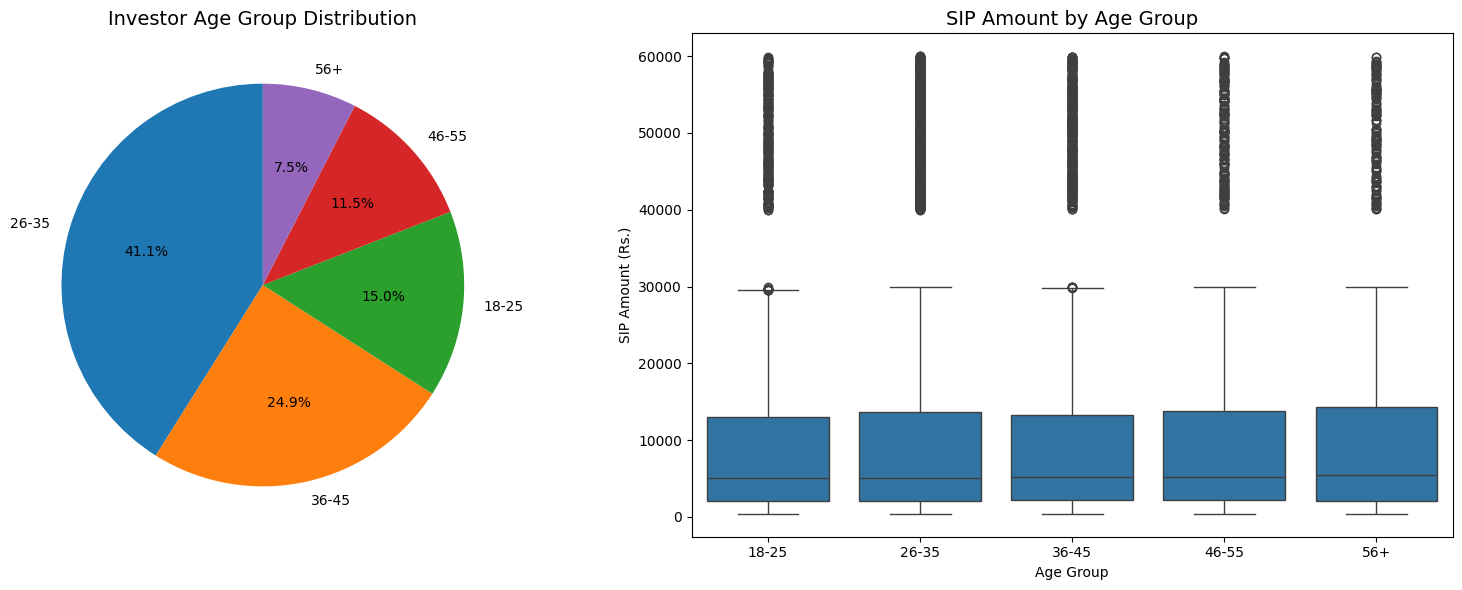

Chart 5 saved


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

age_counts = transactions['age_group'].value_counts()
axes[0].pie(age_counts, labels=age_counts.index, autopct='%1.1f%%', startangle=90)
axes[0].set_title('Investor Age Group Distribution', fontsize=14)


sip_only = transactions[transactions['transaction_type'] == 'SIP']
sns.boxplot(data=sip_only, x='age_group', y='amount_inr', ax=axes[1],
            order=['18-25', '26-35', '36-45', '46-55', '56+'])
axes[1].set_title('SIP Amount by Age Group', fontsize=14)
axes[1].set_xlabel('Age Group')
axes[1].set_ylabel('SIP Amount (Rs.)')

plt.tight_layout()
plt.savefig(r"C:\Users\ASUS\Desktop\Bluestock_MF_Capstone_Project\reports\investor_demographics.png", dpi=150)
plt.show()
print("Chart 5 saved")

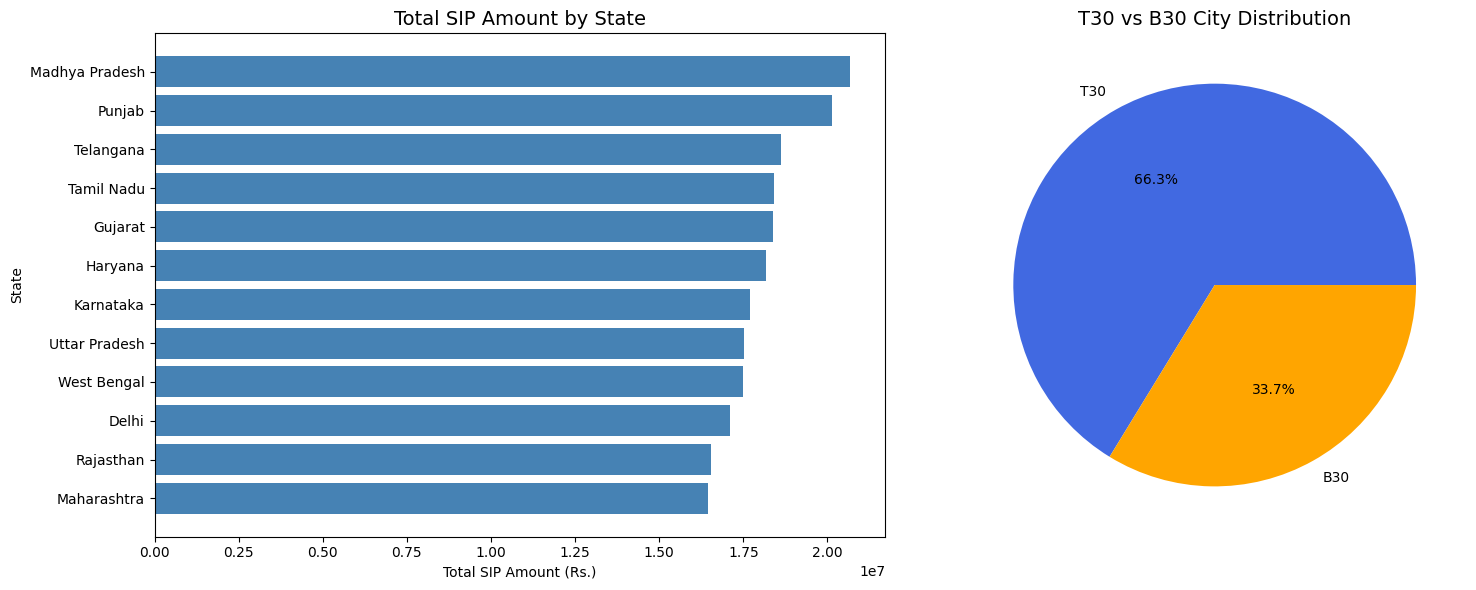

Chart 6 saved


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sip_state = transactions[transactions['transaction_type'] == 'SIP'].groupby('state')['amount_inr'].sum().sort_values()

axes[0].barh(sip_state.index, sip_state.values, color='steelblue')
axes[0].set_title('Total SIP Amount by State', fontsize=14)
axes[0].set_xlabel('Total SIP Amount (Rs.)')
axes[0].set_ylabel('State')

tier_counts = transactions['city_tier'].value_counts()
axes[1].pie(tier_counts, labels=tier_counts.index, 
            autopct='%1.1f%%', colors=['royalblue', 'orange'])
axes[1].set_title('T30 vs B30 City Distribution', fontsize=14)

plt.tight_layout()
plt.savefig(r"C:\Users\ASUS\Desktop\Bluestock_MF_Capstone_Project\reports\geo_distribution.png", dpi=150)
plt.show()
print("Chart 6 saved")

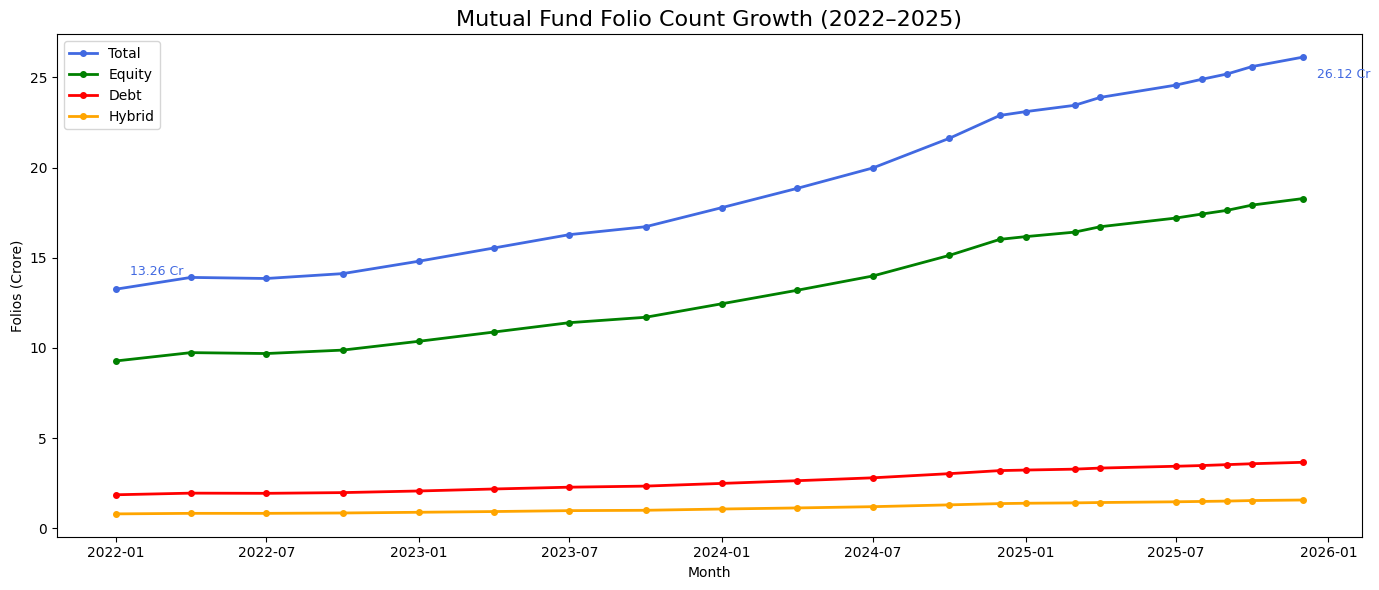

Chart 7 saved


In [17]:
folio['month'] = pd.to_datetime(folio['month'])

plt.figure(figsize=(14, 6))
plt.plot(folio['month'], folio['total_folios_crore'], 
         color='royalblue', linewidth=2, marker='o', markersize=4, label='Total')
plt.plot(folio['month'], folio['equity_folios_crore'], 
         color='green', linewidth=2, marker='o', markersize=4, label='Equity')
plt.plot(folio['month'], folio['debt_folios_crore'], 
         color='red', linewidth=2, marker='o', markersize=4, label='Debt')
plt.plot(folio['month'], folio['hybrid_folios_crore'], 
         color='orange', linewidth=2, marker='o', markersize=4, label='Hybrid')

plt.annotate('13.26 Cr', xy=(folio['month'].iloc[0], 13.26),
             xytext=(10, 10), textcoords='offset points', fontsize=9, color='royalblue')
plt.annotate('26.12 Cr', xy=(folio['month'].iloc[-1], folio['total_folios_crore'].iloc[-1]),
             xytext=(10, -15), textcoords='offset points', fontsize=9, color='royalblue')

plt.title('Mutual Fund Folio Count Growth (2022–2025)', fontsize=16)
plt.xlabel('Month')
plt.ylabel('Folios (Crore)')
plt.legend()
plt.tight_layout()
plt.savefig(r"C:\Users\ASUS\Desktop\Bluestock_MF_Capstone_Project\reports\folio_growth.png", dpi=150)
plt.show()
print("Chart 7 saved")

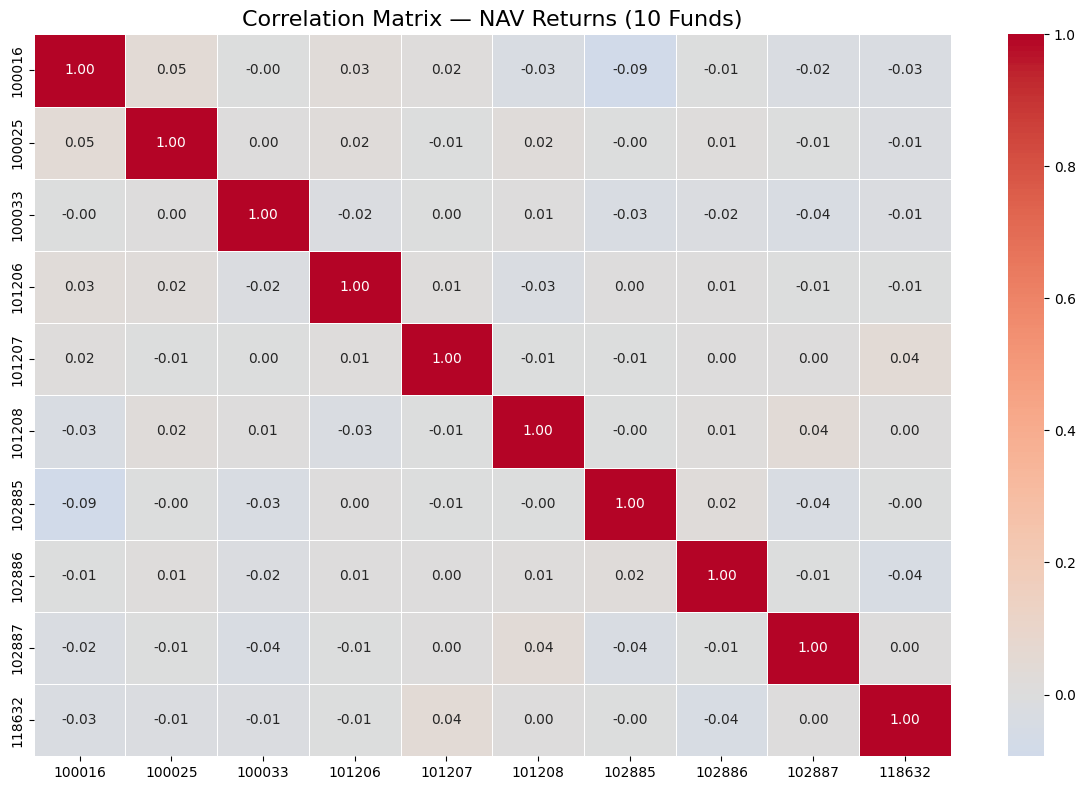

Chart 8 saved


In [18]:
nav['date'] = pd.to_datetime(nav['date'])
nav_pivot = nav.pivot(index='date', columns='amfi_code', values='nav')

returns = nav_pivot.pct_change().dropna()

returns_10 = returns.iloc[:, :10]

fund_names = fund.set_index('amfi_code')['scheme_name'].to_dict()
returns_10.columns = [str(c) for c in returns_10.columns]

corr = returns_10.corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5)
plt.title('Correlation Matrix — NAV Returns (10 Funds)', fontsize=16)
plt.tight_layout()
plt.savefig(r"C:\Users\ASUS\Desktop\Bluestock_MF_Capstone_Project\reports\correlation_matrix.png", dpi=150)
plt.show()
print("Chart 8 saved")

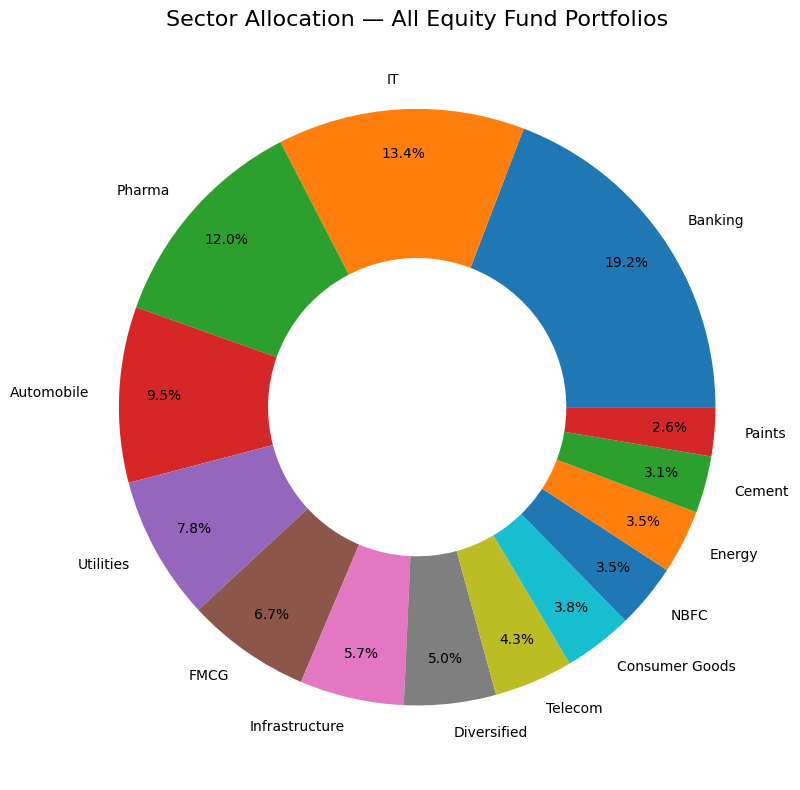

Chart 9 saved


In [20]:
sector_weights = portfolio.groupby('sector')['weight_pct'].sum().sort_values(ascending=False)

plt.figure(figsize=(12, 8))
wedges, texts, autotexts = plt.pie(sector_weights, 
                                    labels=sector_weights.index,
                                    autopct='%1.1f%%',
                                    pctdistance=0.85,
                                    wedgeprops=dict(width=0.5))

plt.title('Sector Allocation — All Equity Fund Portfolios', fontsize=16)
plt.tight_layout()
plt.savefig(r"C:\Users\ASUS\Desktop\Bluestock_MF_Capstone_Project\reports\sector_allocation.png", dpi=150)
plt.show()
print("Chart 9 saved")

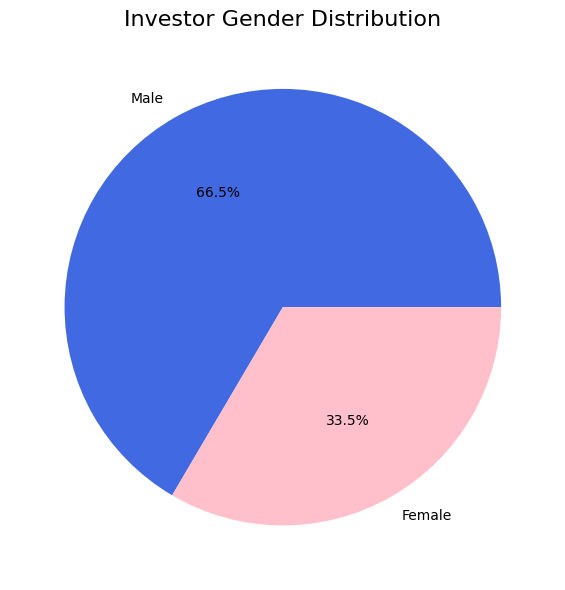

Chart 10 saved


In [21]:
gender_counts = transactions['gender'].value_counts()

plt.figure(figsize=(8, 6))
plt.pie(gender_counts, labels=gender_counts.index, 
        autopct='%1.1f%%', colors=['royalblue', 'pink'])
plt.title('Investor Gender Distribution', fontsize=16)
plt.tight_layout()
plt.savefig(r"C:\Users\ASUS\Desktop\Bluestock_MF_Capstone_Project\reports\gender_distribution.png", dpi=150)
plt.show()
print("Chart 10 saved")

C:\Users\ASUS\AppData\Local\Temp\ipykernel_12500\987029689.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=payment_counts.index, y=payment_counts.values, palette='viridis')


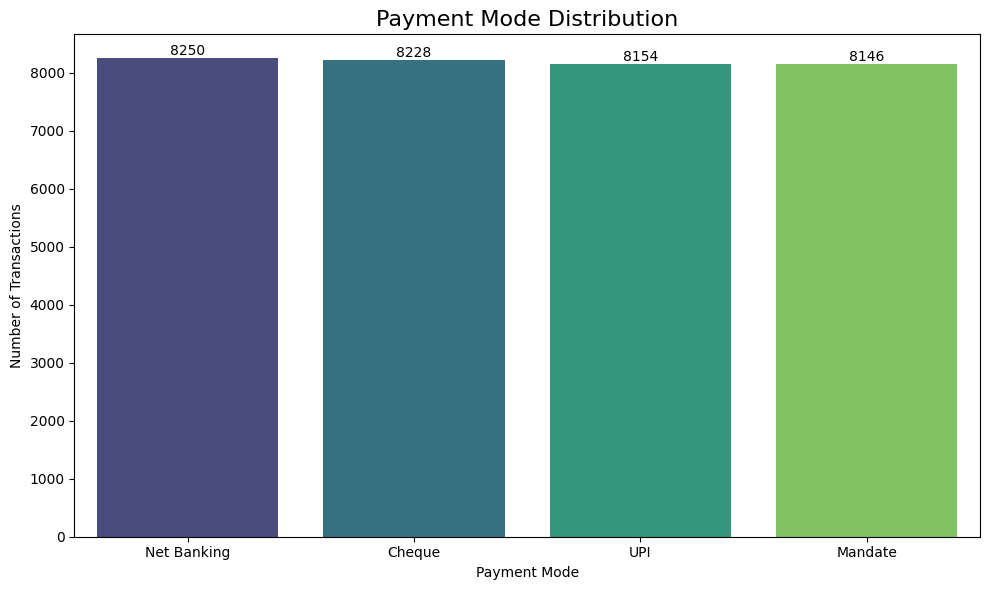

Chart 11 saved


In [22]:
payment_counts = transactions['payment_mode'].value_counts()

plt.figure(figsize=(10, 6))
sns.barplot(x=payment_counts.index, y=payment_counts.values, palette='viridis')
plt.title('Payment Mode Distribution', fontsize=16)
plt.xlabel('Payment Mode')
plt.ylabel('Number of Transactions')
for i, v in enumerate(payment_counts.values):
    plt.text(i, v + 50, str(v), ha='center', fontsize=10)
plt.tight_layout()
plt.savefig(r"C:\Users\ASUS\Desktop\Bluestock_MF_Capstone_Project\reports\payment_mode.png", dpi=150)
plt.show()
print("Chart 11 saved")

C:\Users\ASUS\AppData\Local\Temp\ipykernel_12500\249336672.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=risk_counts.index, y=risk_counts.values, palette='RdYlGn')


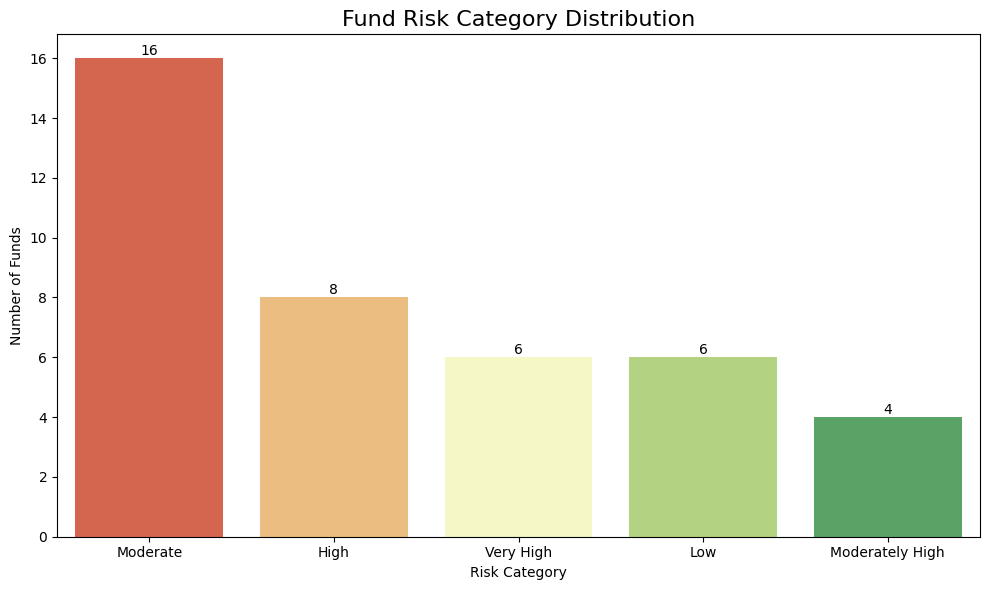

Chart 12 saved


In [23]:
risk_counts = fund['risk_category'].value_counts()

plt.figure(figsize=(10, 6))
sns.barplot(x=risk_counts.index, y=risk_counts.values, palette='RdYlGn')
plt.title('Fund Risk Category Distribution', fontsize=16)
plt.xlabel('Risk Category')
plt.ylabel('Number of Funds')
for i, v in enumerate(risk_counts.values):
    plt.text(i, v + 0.1, str(v), ha='center', fontsize=10)
plt.tight_layout()
plt.savefig(r"C:\Users\ASUS\Desktop\Bluestock_MF_Capstone_Project\reports\risk_category.png", dpi=150)
plt.show()
print("Chart 12 saved")

C:\Users\ASUS\AppData\Local\Temp\ipykernel_12500\1823604592.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_sharpe, x='sharpe_ratio', y='scheme_name', palette='Blues_r')


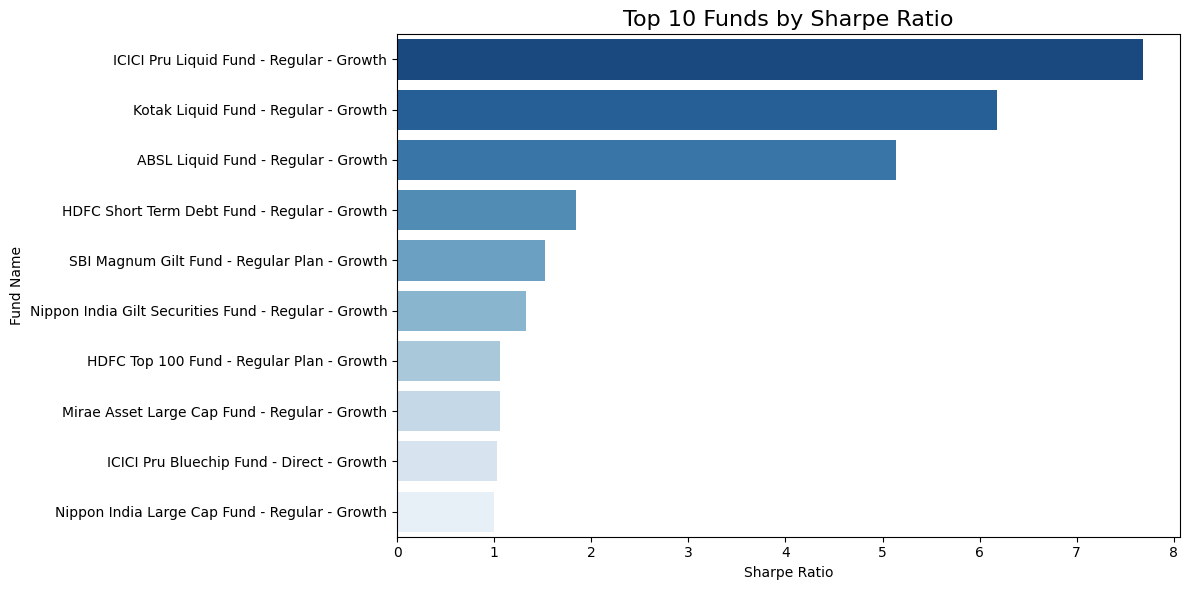

Chart 13 saved


In [24]:
top_sharpe = performance.nlargest(10, 'sharpe_ratio')[['scheme_name', 'sharpe_ratio']]

plt.figure(figsize=(12, 6))
sns.barplot(data=top_sharpe, x='sharpe_ratio', y='scheme_name', palette='Blues_r')
plt.title('Top 10 Funds by Sharpe Ratio', fontsize=16)
plt.xlabel('Sharpe Ratio')
plt.ylabel('Fund Name')
plt.tight_layout()
plt.savefig(r"C:\Users\ASUS\Desktop\Bluestock_MF_Capstone_Project\reports\top_sharpe.png", dpi=150)
plt.show()
print("Chart 13 saved")

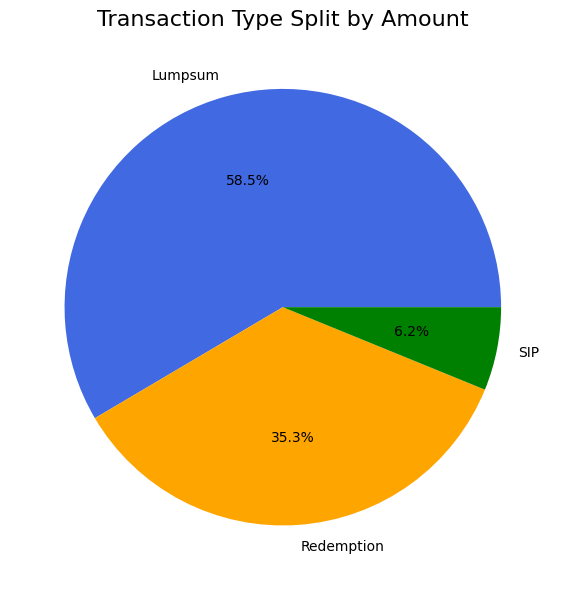

Chart 14 saved


In [25]:
tx_split = transactions.groupby('transaction_type')['amount_inr'].sum()

plt.figure(figsize=(8, 6))
plt.pie(tx_split, labels=tx_split.index, 
        autopct='%1.1f%%', colors=['royalblue', 'orange', 'green'])
plt.title('Transaction Type Split by Amount', fontsize=16)
plt.tight_layout()
plt.savefig(r"C:\Users\ASUS\Desktop\Bluestock_MF_Capstone_Project\reports\transaction_split.png", dpi=150)
plt.show()
print("Chart 14 saved")

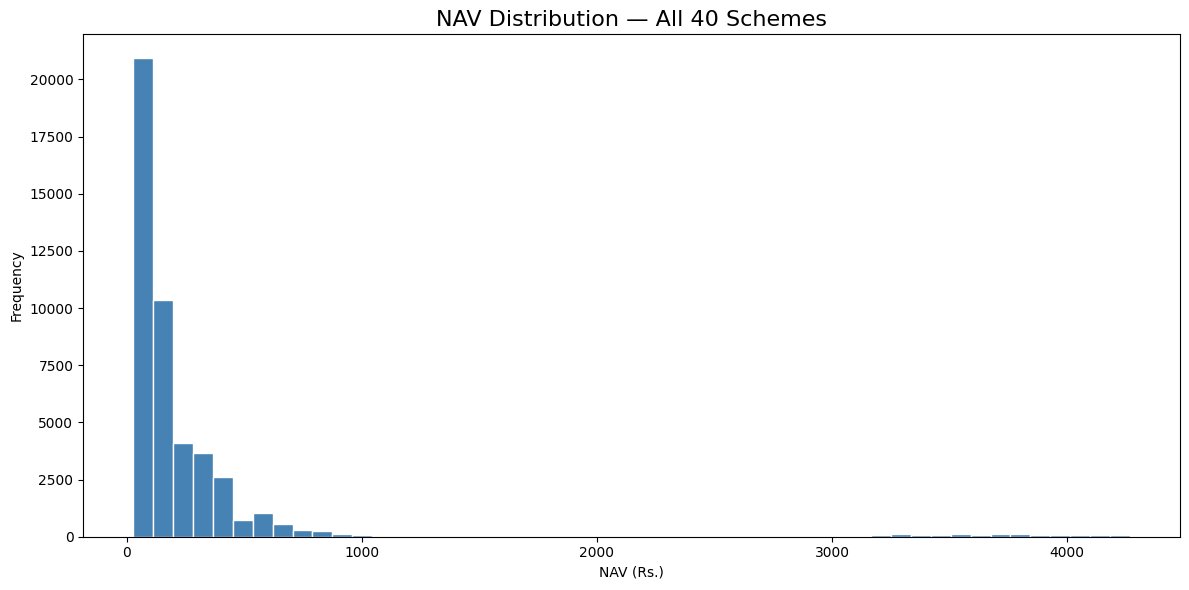

Chart 15 saved


In [26]:
plt.figure(figsize=(12, 6))
plt.hist(nav['nav'], bins=50, color='steelblue', edgecolor='white')
plt.title('NAV Distribution — All 40 Schemes', fontsize=16)
plt.xlabel('NAV (Rs.)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.savefig(r"C:\Users\ASUS\Desktop\Bluestock_MF_Capstone_Project\reports\nav_distribution.png", dpi=150)
plt.show()
print("Chart 15 saved")